##Celebrity Face Identification using Deep Learning - Baseline Model
**DATA 4380 – Computer Vision Project**

**Team Members:**  
- Sidhantaa
- Tiffany
- Alain



This notebook implements our initial CNN model on the celebrity dataset to establish a performance benchmark

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 52.9M/52.9M [00:03<00:00, 15.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1


## Making sure there are 18 classes

In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files))

/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1 0
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset 0
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset/Tom Hanks 100
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset/Jennifer Lawrence 100
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset/Will Smith 100
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset/Johnny Depp 100
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset/Leonardo DiCaprio 100
/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset/Natalie Portman 100
/root/.cache/kagglehub/datasets/vishesh1412/cel

Found 17 classes:
['Tom Hanks', 'Jennifer Lawrence', 'Will Smith', 'Johnny Depp', 'Leonardo DiCaprio', 'Natalie Portman', 'Hugh Jackman', 'Robert Downey Jr', 'Denzel Washington', 'Tom Cruise', 'Scarlett Johansson', 'Kate Winslet', 'Nicole Kidman', 'Brad Pitt', 'Megan Fox', 'Sandra Bullock', 'Angelina Jolie']

Number of images per class:
Tom Hanks: 100 images
Jennifer Lawrence: 100 images
Will Smith: 100 images
Johnny Depp: 100 images
Leonardo DiCaprio: 100 images
Natalie Portman: 100 images
Hugh Jackman: 100 images
Robert Downey Jr: 100 images
Denzel Washington: 100 images
Tom Cruise: 100 images
Scarlett Johansson: 200 images
Kate Winslet: 100 images
Nicole Kidman: 100 images
Brad Pitt: 100 images
Megan Fox: 100 images
Sandra Bullock: 100 images
Angelina Jolie: 100 images


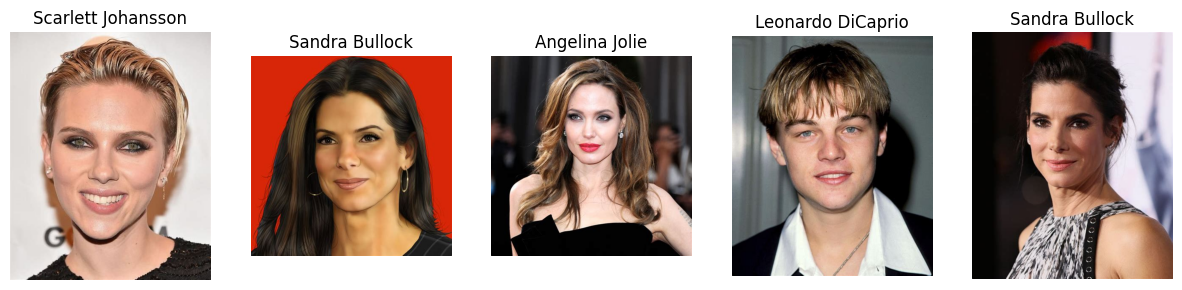

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

# Base path to "Celebrity Faces Dataset" folder
base_path = "/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset"

# Get all class folders (celebrities)
classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
print(f"Found {len(classes)} classes:")
print(classes)

# Count images per class
print("\nNumber of images per class:")
for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith((".jpg", ".png"))]
    print(f"{cls}: {len(images)} images")

# Display a few random images per class
def show_random_images(base_path, classes, num_images=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        cls = random.choice(classes)
        cls_path = os.path.join(base_path, cls)
        img_file = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_file)
        img = Image.open(img_path)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.show()

show_random_images(base_path, classes, num_images=5)


In [ ]:
import os

# Base path to "Celebrity Faces Dataset" folder
base_path = "/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset"

# Get all class folders (celebrities)
classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

# Print number of classes and their names
print(f"Number of classes: {len(classes)}")
print("Classes:", classes)


Number of classes: 17
Classes: ['Tom Hanks', 'Jennifer Lawrence', 'Will Smith', 'Johnny Depp', 'Leonardo DiCaprio', 'Natalie Portman', 'Hugh Jackman', 'Robert Downey Jr', 'Denzel Washington', 'Tom Cruise', 'Scarlett Johansson', 'Kate Winslet', 'Nicole Kidman', 'Brad Pitt', 'Megan Fox', 'Sandra Bullock', 'Angelina Jolie']


## Split in training-validation-test sets (70/15/15)

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Base dataset path containing the 18 celebrity folders
base_path = "/root/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset"

# Target path for organized dataset
output_path = "celebrity_dataset_split"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create directories for train/val/test
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_path, split), exist_ok=True)

# List only the 18 celebrity classes
classes = [d for d in os.listdir(base_path)
           if os.path.isdir(os.path.join(base_path, d))
           and not d.lower().startswith("0")
           and d.lower() != "celebrity faces dataset"]

print(f"Classes to split: {classes}")

# Split each class separately
for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith((".jpg", ".png"))]

    # Split into train and temp (val+test)
    train_files, temp_files = train_test_split(images, train_size=train_ratio, random_state=42)
    # Split temp into val and test
    val_files, test_files = train_test_split(temp_files, test_size=test_ratio/(test_ratio+val_ratio), random_state=42)

    # Copy files to respective directories
    for split_name, split_files in zip(["train", "val", "test"], [train_files, val_files, test_files]):
        split_cls_path = os.path.join(output_path, split_name, cls)
        os.makedirs(split_cls_path, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(split_cls_path, f))

print("Dataset has been split into train, validation, and test sets.")


Classes to split: ['Tom Hanks', 'Jennifer Lawrence', 'Will Smith', 'Johnny Depp', 'Leonardo DiCaprio', 'Natalie Portman', 'Hugh Jackman', 'Robert Downey Jr', 'Denzel Washington', 'Tom Cruise', 'Scarlett Johansson', 'Kate Winslet', 'Nicole Kidman', 'Brad Pitt', 'Megan Fox', 'Sandra Bullock', 'Angelina Jolie']
Dataset has been split into train, validation, and test sets.


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "celebrity_dataset_split/train",
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "celebrity_dataset_split/val",
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "celebrity_dataset_split/test",
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)


Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.


## Baseline CNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Paths to your dataset splits
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
# Correct num_classes to 17, as inferred from the dataset loading output
num_classes = 17

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

# Normalize images
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Baseline CNN model
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_baseline_cnn(num_classes=num_classes)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.0744 - loss: 2.8629 - val_accuracy: 0.1111 - val_loss: 2.8088
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.0876 - loss: 2.8209 - val_accuracy: 0.1111 - val_loss: 2.7823
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.1372 - loss: 2.7386 - val_accuracy: 0.1741 - val_loss: 2.6012
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.1983 - loss: 2.4910 - val_accuracy: 0.1926 - val_loss: 2.4869
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.2592 - loss: 2.2974 - val_accuracy: 0.2296 - val_loss: 2.4212
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3625 - loss: 1.9983 - val_accuracy: 0.2556 - val_loss: 2.4631
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.4094 - loss: 1.7553 - val_accuracy: 0.2778 - val_loss: 2.5325
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5023 - loss: 1.4505 - val_accuracy: 0.2815 - val_loss:

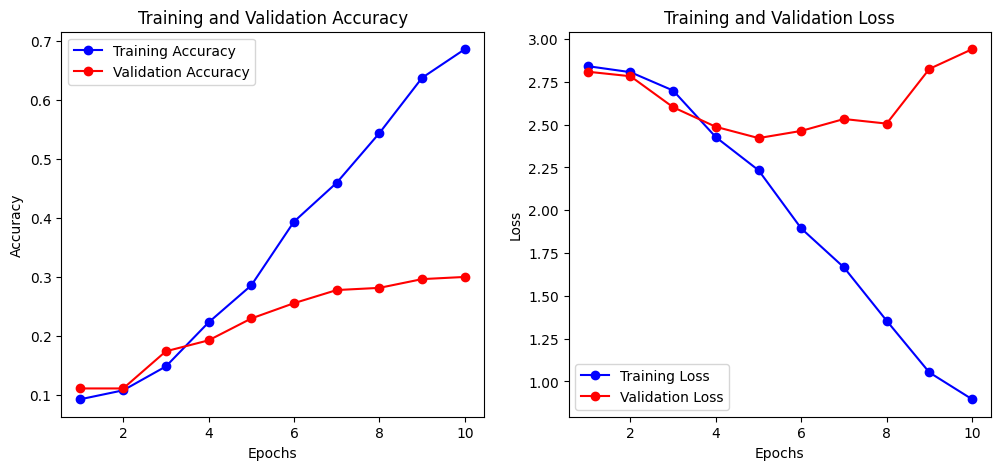

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

# Plot Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


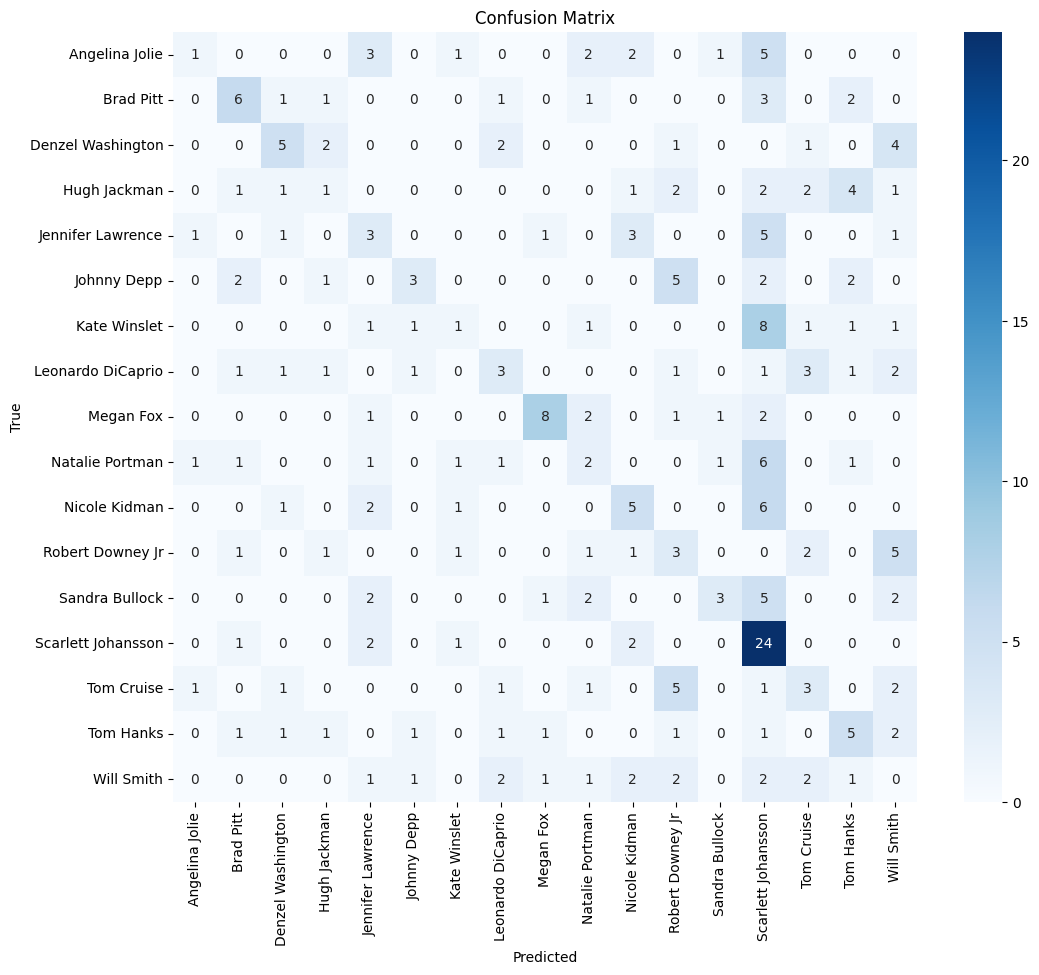

Classification Report:
                    precision    recall  f1-score   support

    Angelina Jolie       0.25      0.07      0.11        15
         Brad Pitt       0.43      0.40      0.41        15
 Denzel Washington       0.42      0.33      0.37        15
      Hugh Jackman       0.12      0.07      0.09        15
 Jennifer Lawrence       0.19      0.20      0.19        15
       Johnny Depp       0.43      0.20      0.27        15
      Kate Winslet       0.17      0.07      0.10        15
 Leonardo DiCaprio       0.27      0.20      0.23        15
         Megan Fox       0.67      0.53      0.59        15
   Natalie Portman       0.15      0.13      0.14        15
     Nicole Kidman       0.31      0.33      0.32        15
  Robert Downey Jr       0.14      0.20      0.17        15
    Sandra Bullock       0.50      0.20      0.29        15
Scarlett Johansson       0.33      0.80      0.47        30
        Tom Cruise       0.21      0.20      0.21        15
         Tom Han

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Re-load test_ds to get class_names before normalization
# Or, even better, get it from train_ds or val_ds right after its creation if not already stored.
# Assuming train_ds was created by image_dataset_from_directory and retains class_names.
# We will get class names from the un-mapped train_ds created in the previous cell.
# If this is being run independently, one would recreate it here.
# For continuity, let's assume `train_ds` still holds the original dataset without map operation.
# However, the notebook state shows train_ds, val_ds, test_ds are already mapped.
# So, we need to explicitly get them before the mapping. Let's assume the unmapped versions exist
# or recreate them if necessary. Given the prior cell, they were created.

# To safely get class_names, we need to get it from a dataset created by image_dataset_from_directory
# *before* any .map() operations that turn it into a _MapDataset.
# The easiest way is to re-create a temporary dataset object for class_names.
temp_test_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, # test_path is defined in the previous cell
    image_size=(img_height, img_width), # img_height, img_width are defined in the previous cell
    batch_size=32,
    label_mode="categorical",
    shuffle=False # Shuffle not needed for just getting class names
)

class_names = temp_test_ds_for_names.class_names

# 1. Get true labels and predictions
y_true = []
y_pred = []

# Iterate over the *normalized* test_ds for actual predictions
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


## 100 epochs baseline

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Paths to your dataset splits
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
# Correct num_classes to 17, as inferred from the dataset loading output
num_classes = 17

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

# Normalize images
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Baseline CNN model
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_baseline_cnn(num_classes=num_classes)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.0840 - loss: 2.9345 - val_accuracy: 0.1111 - val_loss: 2.7590
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.1172 - loss: 2.7394 - val_accuracy: 0.1556 - val_loss: 2.5877
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.1835 - loss: 2.5485 - val_accuracy: 0.1741 - val_loss: 2.4835
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.2694 - loss: 2.3093 - val_accuracy: 0.2519 - val_loss: 2.3373
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3659 - loss: 1.9494 - val_accuracy: 0.2667 - val_loss: 2.2653
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.4737 - loss: 1.6104 - val_accuracy: 0.2667 - val_loss: 2.3299
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.5578 - loss: 1.3737 - val_accuracy: 0.2741 - val_loss: 2.5736
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.6186 - loss: 1.1538 - val_accuracy: 0.2667 - val_loss: 2.8

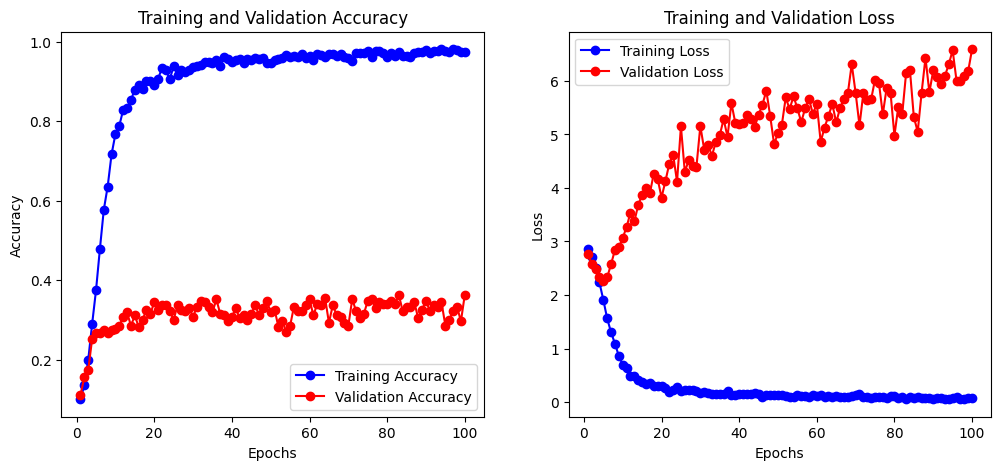

In [ ]:
# Extract metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

# Plot Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


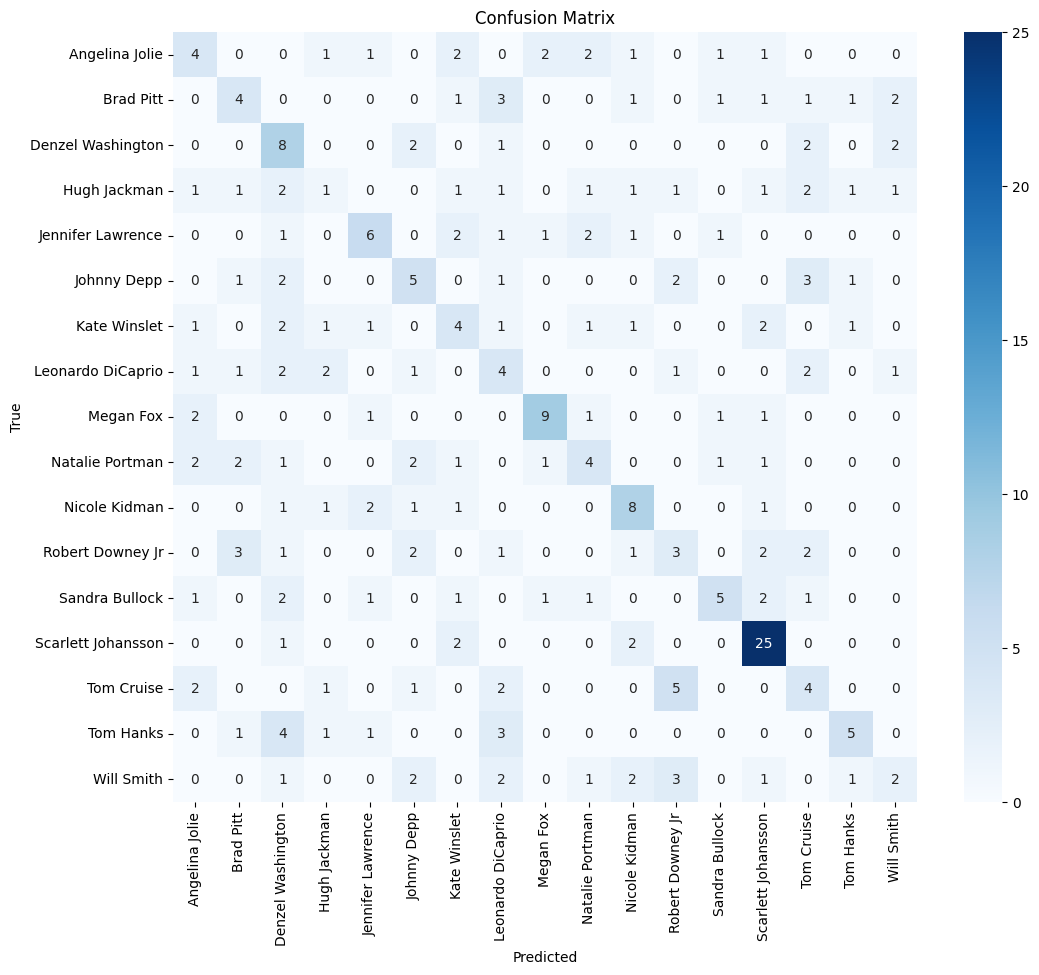

Classification Report:
                    precision    recall  f1-score   support

    Angelina Jolie       0.29      0.27      0.28        15
         Brad Pitt       0.31      0.27      0.29        15
 Denzel Washington       0.29      0.53      0.37        15
      Hugh Jackman       0.12      0.07      0.09        15
 Jennifer Lawrence       0.46      0.40      0.43        15
       Johnny Depp       0.31      0.33      0.32        15
      Kate Winslet       0.27      0.27      0.27        15
 Leonardo DiCaprio       0.20      0.27      0.23        15
         Megan Fox       0.64      0.60      0.62        15
   Natalie Portman       0.31      0.27      0.29        15
     Nicole Kidman       0.44      0.53      0.48        15
  Robert Downey Jr       0.20      0.20      0.20        15
    Sandra Bullock       0.50      0.33      0.40        15
Scarlett Johansson       0.66      0.83      0.74        30
        Tom Cruise       0.24      0.27      0.25        15
         Tom Han

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Re-load test_ds to get class_names before normalization
# Or, even better, get it from train_ds or val_ds right after its creation if not already stored.
# Assuming train_ds was created by image_dataset_from_directory and retains class_names.
# We will get class names from the un-mapped train_ds created in the previous cell.
# If this is being run independently, one would recreate it here.
# For continuity, let's assume `train_ds` still holds the original dataset without map operation.
# However, the notebook state shows train_ds, val_ds, test_ds are already mapped.
# So, we need to explicitly get them before the mapping. Let's assume the unmapped versions exist
# or recreate them if necessary. Given the prior cell, they were created.

# To safely get class_names, we need to get it from a dataset created by image_dataset_from_directory
# *before* any .map() operations that turn it into a _MapDataset.
# The easiest way is to re-create a temporary dataset object for class_names.
temp_test_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, # test_path is defined in the previous cell
    image_size=(img_height, img_width), # img_height, img_width are defined in the previous cell
    batch_size=32,
    label_mode="categorical",
    shuffle=False # Shuffle not needed for just getting class names
)

class_names = temp_test_ds_for_names.class_names

# 1. Get true labels and predictions
y_true = []
y_pred = []

# Iterate over the *normalized* test_ds for actual predictions
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))